# Notebook 1a: Selecting Thresholds for LUI‑Based Site Classification

---

**Author**: Laura Steel Pascual  
**Date**: February 2026  
**Project**: Decoding Environmental Status with eDNA and Supervised Machine Learning: Insights into Ecological Condition and Species‑Level Predictors in Solomon Island Rivers

---

## Overview
This notebook documents the exploratory steps used to convert continuous Land Use Intensification (LUI) values (derived from annual Sentinel‑2 land‑use/land‑cover imagery) into a binary classification of anthropogenically **impacted** (1) versus minimally disturbed **reference** (0) sites.

Here, LUI distributions are examined across sites, years, and buffer distances to identify thresholds that are both ecologically meaningful for Guadalcanal’s largely pristine rivers and statistically suitable for supervised learning.

**Purpose**: 
- Explore the distribution of LUI values across buffers and years.
- Test candidate thresholds for converting LUI into binary classes.
- Select thresholds that provide ecologically defensible separation between minimally disturbed and human‑impacted sites.
- Ensure resulting class balances are adequate for model training.

This analysis supports the final choice of **0.03125 and 0.0625** as the two LUI thresholds (the *y* variable) used in subsequent modelling.

**Paper Reference**: 2. Materials & Methods -> 2.2 Site Classification

---

## 1. Setup

In [30]:
# Import libraries (install if necessary, !pip install [library])
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Create output directories
os.makedirs('results/preprocessed', exist_ok=True)

print(f'Pandas version: {pd.__version__}')
print(f'Matplotlib version: {matplotlib.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Seaborn version: {sns.__version__}')

Pandas version: 2.3.2
Matplotlib version: 3.9.2
NumPy version: 1.24.4
Seaborn version: 0.12.2


## 2. Load LUI Data

Load pre‑calculated LUI scores for all 47 sites across four buffer distances (100 m, 300 m, 500 m, 1000 m) for 2017–2023 (excluding 2021 due to cloud cover). LUI values are derived from Sentinel‑2 Land use/land cover data (10 m resolution) using *LUI = 5 × (% built area) + 3 × (% agricultural) + (% pasture)*.

This captures a gradient of human modification around each sampling location, with buffer sizes representing increasing spatial context (from immediate riparian conditions to broader catchment‑scale pressures).

In [32]:
# Define data directory
DATA_DIR = 'data'

# Load datasets
LUI_ALL = pd.read_excel(os.path.join(DATA_DIR, 'LUI_ALL.xlsx'))

# Create working copies
lui_full = LUI_ALL.copy()

print(f'Loaded LUI data: {lui_full.shape}')

# Quick inspection
print('\nLUI data preview:')
display(lui_full.head())

Loaded LUI data: (47, 25)

LUI data preview:


,SiteID,2017LUI1000,2017LUI100,2017LUI300,2017LUI500,2018LUI1000,2018LUI100,2018LUI300,2018LUI500,2019LUI1000,...,2020LUI300,2020LUI500,2022LUI1000,2022LUI100,2022LUI300,2022LUI500,2023LUI1000,2023LUI100,2023LUI300,2023LUI500
0,Charigaveheu_8.2,0.026195,0.0,0.0,0.003391,0.025543,0.0,0.0000,0.007956,0.021308,...,0.000000,0.004826,0.031115,0.0,0.000000,0.015912,0.026260,0.0,0.000000,0.021390
1,Charigaveheu_8.3,0.032467,0.0,0.0,0.011722,0.031783,0.0,0.0141,0.011982,0.028588,...,0.013377,0.007424,0.042866,0.0,0.014461,0.026048,0.034391,0.0,0.040853,0.015759
2,Charimalenga_7.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
3,Charimalenga_7.1,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.005801,0.0,0.000000,0.000000
4,Charimalenga_7.2,0.022678,0.0,0.0,0.034672,0.002863,0.0,0.0000,0.007690,0.000423,...,0.000000,0.007169,0.015130,0.0,0.000000,0.023592,0.014577,0.0,0.000000,0.013947


## 3. Explore LUI distributions across years and buffers
Examines how values vary across years and buffer distances to characterise disturbance patterns and inform threshold selection.

### 3.1 Distributional patterns (histograms)

Histograms of LUI values for each year and buffer are plotted to examine how values are distributed and to see where most sites fall along the disturbance gradient.

**Finding**: LUI values are strongly right‑skewed, with most sites exhibiting values near zero across all years and buffers. This pattern is consistent with the predominantly pristine condition of catchments on Guadalcanal.

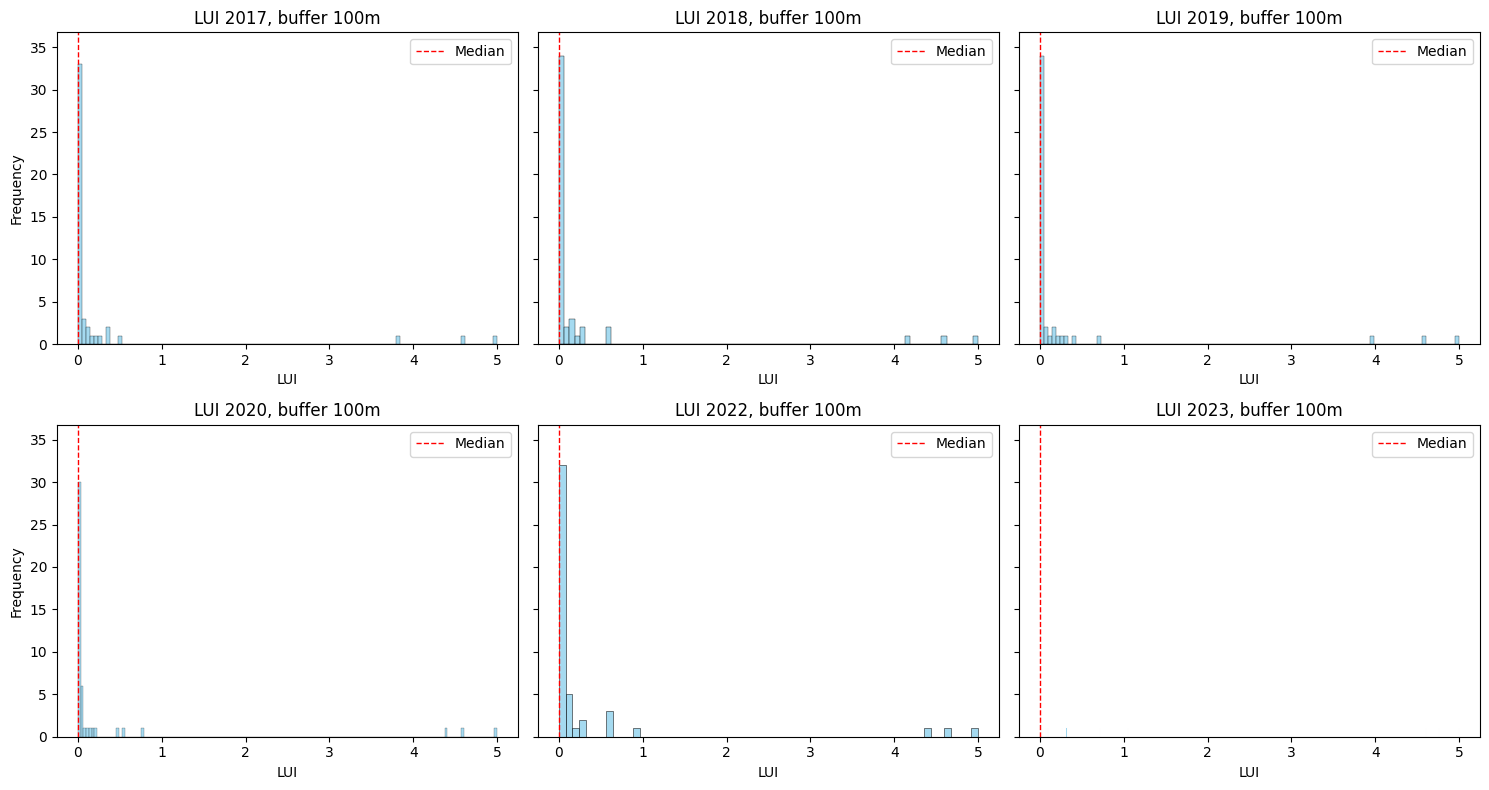

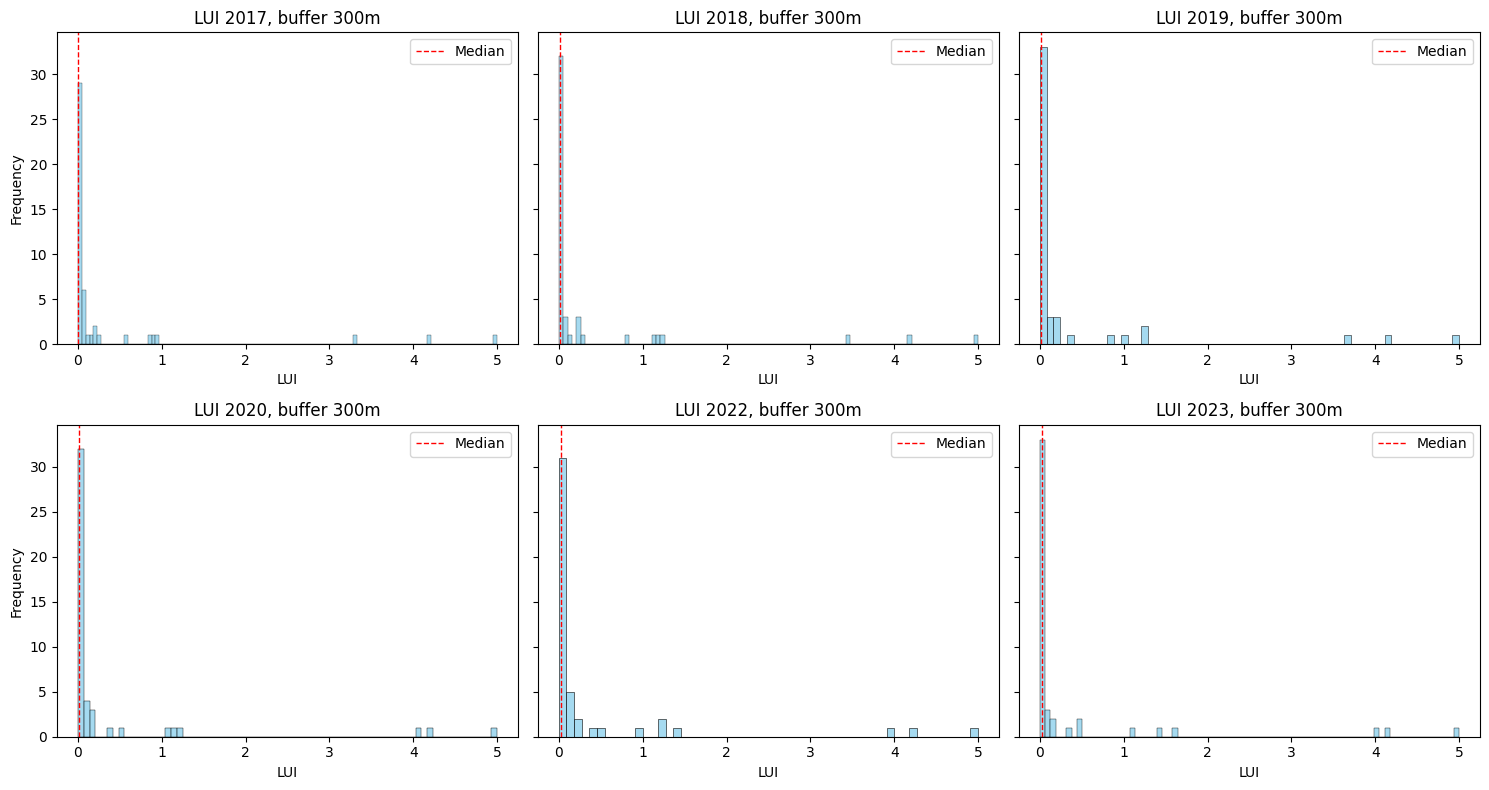

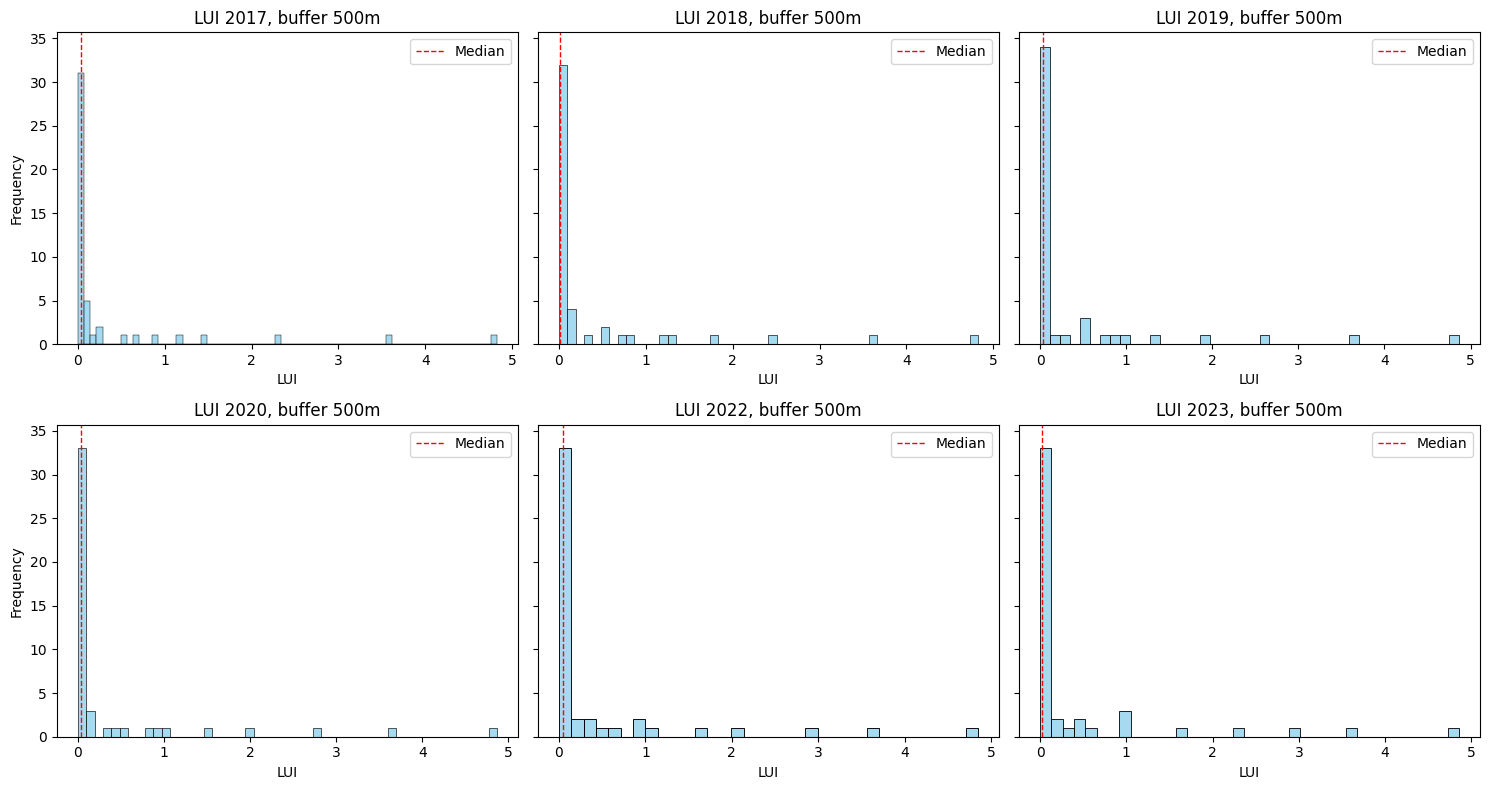

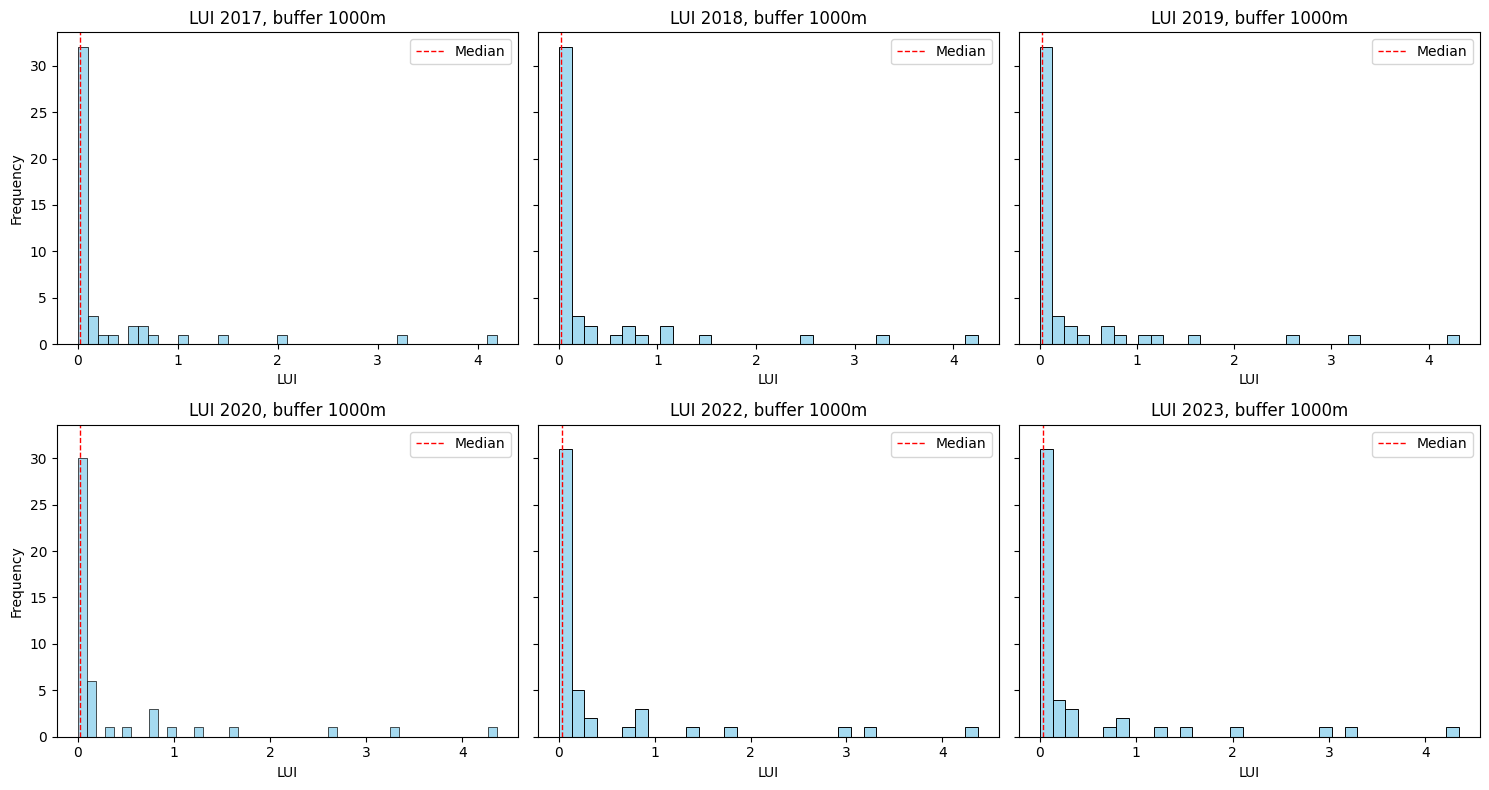

In [34]:
buffers = [100, 300, 500, 1000]
years = [2017, 2018, 2019, 2020, 2022, 2023]

for buf in buffers:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
    axes = axes.flatten()
    for idx, yr in enumerate(years):
        col = f"{yr}LUI{buf}"
        data = lui_full[col]
        bin_width = 2 * (np.percentile(data, 75) - np.percentile(data, 25)) / np.cbrt(len(data))
        bins = int((data.max() - data.min()) / bin_width) if bin_width > 0 else 5
        sns.histplot(data, bins=bins, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'LUI {yr}, buffer {buf}m')
        axes[idx].set_xlabel('LUI')
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(data.median(), color='red', linestyle='dashed', linewidth=1, label='Median')
        axes[idx].legend()
    plt.tight_layout()
    plt.show()

### 3.2 Temporal patterns (site‑level trajectories)
Site‑by‑site LUI trajectories are plotted across years to assess temporal patterns and determine how to summarise disturbance over time.

**Finding**: Site‑level LUI trajectories show modest increases at many locations, but interannual variability is substantial. Consequently, the maximum LUI value per site provides the most stable summary of disturbance, particularly given that predictor variables were collected in 2024.

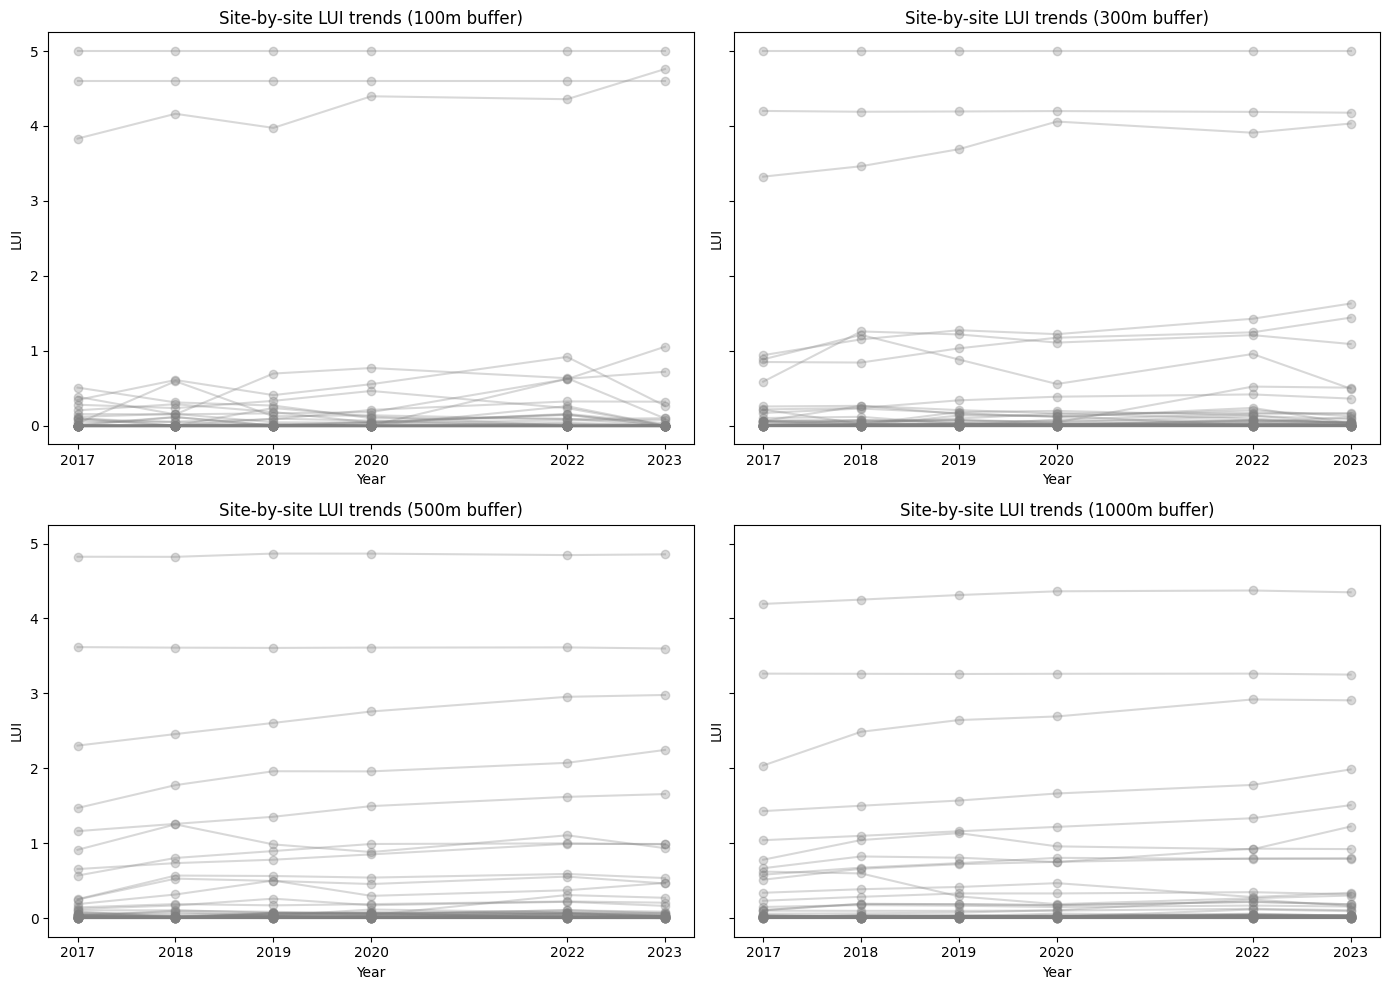

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, buf in zip(axes, buffers):
    for idx, row in lui_full.iterrows():
        lui_values = [row[f"{year}LUI{buf}"] for year in years]
        ax.plot(years, lui_values, marker='o', alpha=0.3, color='grey')
    ax.set_title(f'Site-by-site LUI trends ({buf}m buffer)')
    ax.set_xlabel('Year')
    ax.set_ylabel('LUI')
    ax.set_xticks(years)
    
plt.tight_layout()
plt.show()

## 4. Deriving a Single Disturbance Metric per Site
Interannual variability necessitates a single disturbance metric per site. The maximum LUI value across years is therefore calculated for each buffer, providing a conservative summary of peak land‑use intensity.

In [38]:
# Safety copy
lui_max = lui_full.copy()

# Compute maximum LUI across years for each buffer
for buf in buffers:
    cols = [f"{year}LUI{buf}" for year in years if f"{year}LUI{buf}" in lui_max.columns]
    lui_max[f"MaxLUI_{buf}m"] = lui_max[cols].max(axis=1, skipna=True)

# Extract only site identifiers + MaxLUI columns
maxlui_cols = ['SiteID'] + [f"MaxLUI_{buf}m" for buf in buffers if f"MaxLUI_{buf}m" in lui_max.columns]
lui_max_only = lui_max[maxlui_cols]

# Save the resulting dataset for future use
output_path = "results/preprocessed/lui_maxLUI_per_site.xlsx"
lui_max_only.to_excel(output_path, index=False)

print(f"MaxLUI dataset saved: {lui_max_only.shape[0]} rows × {lui_max_only.shape[1]} columns")

# Quick inspection
print('\nPreview of MaxLUI data:')
display(lui_max_only.head())


MaxLUI dataset saved: 47 rows × 5 columns

Preview of MaxLUI data:


,SiteID,MaxLUI_100m,MaxLUI_300m,MaxLUI_500m,MaxLUI_1000m
0,Charigaveheu_8.2,0.013029,0.004345,0.021390,0.031115
1,Charigaveheu_8.3,0.019544,0.040853,0.026048,0.042866
2,Charimalenga_7.0,0.000000,0.000000,0.000000,0.000000
3,Charimalenga_7.1,0.000000,0.000000,0.000000,0.005801
4,Charimalenga_7.2,0.000000,0.000000,0.034672,0.022678


## 5. Exploring Proportional Distributions of MaxLUI categories

With a single disturbance metric now defined for each site and buffer, proportional distributions are used to characterise how frequently sites fall into different levels of land‑use intensity. MaxLUI values are grouped into broad categories (0, >0–1, >1–3, >3) to summarise the prevalence of low, moderate, and high disturbance across buffers.

**Finding**: Low‑disturbance sites dominate across all buffers, with MaxLUI values mostly falling in the 0 and 0–1 categories. The proportion of sites with MaxLUI = 0 declines sharply as buffer size increases, reflecting greater detection of human land use at broader spatial scales, while moderate and high disturbance levels remain uncommon.

In [40]:
# Define broad LUI bins and labels
broad_bins = [-0.01, 0, 1, 3, 100]
broad_labels = ['0', '0–1', '1–3', '>3']

broad_results = {}

for buf in buffers:
    col = f"MaxLUI_{buf}m"
    binned = pd.cut(lui_max_only[col], bins=broad_bins, labels=broad_labels, include_lowest=True)
    props = binned.value_counts(normalize=True).sort_index()
    broad_results[buf] = props

# Combine into a single dataframe for side-by-side comparison
broad_df = pd.DataFrame(broad_results)
print("Broad MaxLUI category proportions:")
display(broad_df)


Broad MaxLUI category proportions:


,100,300,500,1000
0,0.489362,0.255319,0.106383,0.042553
0–1,0.425532,0.595745,0.765957,0.829787
1–3,0.021277,0.085106,0.085106,0.085106
>3,0.063830,0.063830,0.042553,0.042553


## 6. Threshold Testing Using MaxLUI

Building on the broad proportional patterns, threshold testing is performed directly on MaxLUI values to identify meaningful cut‑points for classifying sites as impacted/disturbed within the context of a comparatively untouched landscape. Candidate thresholds correspond to simple fractional coverages of human land‑use types within each buffer:

- 0.015625 (1/64 pastureland equivalent).
- 0.03125 (1/32 pastureland equivalent).
- 0.0625 (1/16 pastureland equivalent).
- 0.125 (1/8 pastureland equivalent).

Pastureland is used as the reference because human activities on Guadalcanal are generally low‑intensity, making these fractions ecologically interpretable increments of disturbance. The thresholds span the range where MaxLUI distributions begin to diverge and where transitions from minimal to moderate disturbance are most evident.

Thresholds are evaluated based on:
- Class balance: proportion of sites above vs. below each threshold.
- Distributional separation: whether the threshold lies in a region of meaningful change.
- Ecological interpretability: whether the threshold reflects plausible disturbance levels in predominantly pristine catchments.

**Finding**: The lowest threshold (0.015625) is too conservative, with most sites exceeding it at larger buffers. The highest threshold (0.125) identifies only a small minority of sites as disturbed. The intermediate thresholds (0.03125 and 0.0625) fall within clear transition zones where class proportions shift meaningfully, making them the most informative candidates for distinguishing minimally from moderately disturbed sites.

In [42]:
# Candidate thresholds
thresholds = [0.015625, 0.03125, 0.0625, 0.125]

# Dictionary to store results
threshold_results = {}

for t in thresholds:
    results = {}
    for buf in buffers:
        col = f"MaxLUI_{buf}m"
        below = (lui_max_only[col] <= t).mean()
        above = (lui_max_only[col] > t).mean()
        results[buf] = pd.Series({'≤ threshold (0)': below, '> threshold (1)': above})
    threshold_results[t] = pd.DataFrame(results)

# Display results
for t, df in threshold_results.items():
    print(f"\n--- Threshold = {t} ---")
    display(df)



--- Threshold = 0.015625 ---


,100,300,500,1000
≤ threshold (0),0.510638,0.340426,0.191489,0.12766
> threshold (1),0.489362,0.659574,0.808511,0.87234



--- Threshold = 0.03125 ---


,100,300,500,1000
≤ threshold (0),0.553191,0.468085,0.340426,0.382979
> threshold (1),0.446809,0.531915,0.659574,0.617021



--- Threshold = 0.0625 ---


,100,300,500,1000
≤ threshold (0),0.574468,0.531915,0.489362,0.617021
> threshold (1),0.425532,0.468085,0.510638,0.382979



--- Threshold = 0.125 ---


,100,300,500,1000
≤ threshold (0),0.659574,0.638298,0.702128,0.659574
> threshold (1),0.340426,0.361702,0.297872,0.340426


## 7. Threshold Selection Decision

Based on threshold-testing results, **two thresholds (0.03125 and 0.0625) are selected** for subsequent modelling.

**Rationale**:
* **Class balance**: Both thresholds yield 30-62% impacted sites across buffers, avoiding extreme imbalance.
* **Ecological meaning**: Correspond to 1/32 and 1/16 pastureland equivalents—meaningful disturbance levels for Guadalcanal's predominantly pristine rivers.
* **Distributional position**: Fall within clear transition zones where MaxLUI values shift from low to moderate disturbance.

Alternative thresholds (0.015625, 0.125) were too lenient or too strict, respectively.

**Output**: Binary classifications for 8 combinations (4 buffers × 2 thresholds). Sites with MaxLUI values exceeding the threshold are classified as impacted (1), while those at or below the threshold are classified as reference (0). These are exported for future use in model fitting, validation, and comparison across spatial scales.

In [44]:
# Selected buffers and thresholds
buffers = [100, 300, 500, 1000]
thresholds = [0.03125, 0.0625]
id_col = 'SiteID'

# Create impact classification dataframe
impact_classification = pd.DataFrame({id_col: lui_max_only[id_col]})

# Generate binary impacted classifications
for buf in buffers:
    for thresh in thresholds:
        col = f"MaxLUI_{buf}m"
        new_col = f"Impacted_{buf}m_{thresh}"
        impact_classification[new_col] = (lui_max_only[col] > thresh).astype(int)

# Set index for clarity
impact_classification.set_index(id_col, inplace=True)

# Preview
display(impact_classification.head())

# Save combined Excel file only
output_path = "results/preprocessed/impact_classification_output.xlsx"

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    impact_classification.to_excel(writer, sheet_name='Impact Classification')

print(f"Binary impact classification dataset saved: {impact_classification.shape[0]} rows × {impact_classification.shape[1]} columns")


,Impacted_100m_0.03125,Impacted_100m_0.0625,Impacted_300m_0.03125,Impacted_300m_0.0625,Impacted_500m_0.03125,Impacted_500m_0.0625,Impacted_1000m_0.03125,Impacted_1000m_0.0625
SiteID,,,,,,,,
Charigaveheu_8.2,0,0,0,0,0,0,0,0
Charigaveheu_8.3,0,0,1,0,0,0,1,0
Charimalenga_7.0,0,0,0,0,0,0,0,0
Charimalenga_7.1,0,0,0,0,0,0,0,0
Charimalenga_7.2,0,0,0,0,1,0,0,0


Binary impact classification dataset saved: 47 rows × 8 columns


## 8. Summary

**Outputs** (`results/preprocessed/`):

- **Impact metric**: `lui_maxLUI_per_site.xlsx`
- **Binary classifications**: `impact_classification_output.xlsx`

## Next Steps

Return to Notebook `1_Data_Preprocessing.ipynb`, where these outputs are integrated into the data processing pipeline and modelling steps.
